# ABUK Stock Return Prediction Using a Multilayer Perceptron

## Introduction

This project investigates whether a Multilayer Perceptron (MLP) neural network can predict daily stock returns for ABUK using historical return information.

The project explores the effect of neural network architecture and training duration by varying the number of hidden layers, number of neurons and number of training epochs. The MLP is also compared with a naive prediction baseline and a simple buy-and-hold investment strategy.

In [7]:
import sys
import os

while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch
import torch.nn as nn

df = pd.read_csv("data/egx/ABUK.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


## 1. Loading and Exploring the Data

The ABUK historical stock dataset is loaded using pandas. The dataset contains daily observations including the date, opening price, highest price, lowest price, closing price and trading volume.

In [2]:
# Load ABUK stock data

df = pd.read_csv("data/egx/ABUK.csv")

# Convert date column to actual dates
df["date"] = pd.to_datetime(df["date"])

# Make sure the data is sorted from oldest to newest
df = df.sort_values("date").reset_index(drop=True)

# Show the first few rows
df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


In [3]:
print("Number of rows:", len(df))
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Number of rows: 2857
Start date: 2015-01-04 00:00:00
End date: 2026-07-30 00:00:00

Missing values:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Data types:
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object


## 2. Calculating Daily Returns

Daily returns are calculated from the closing prices. Returns are used instead of raw prices because the objective is to predict the change in the stock price rather than its absolute price level.

In [9]:
# Calculate daily returns
df["return"] = df["close"].pct_change()

# Remove the first row because it has no previous day
df = df.dropna(subset=["return"]).reset_index(drop=True)

# Check
df[["date", "close", "return"]].head(10)

,date,close,return
0,2015-01-05,10.794666,0.012000
1,2015-01-06,10.800000,0.000494
2,2015-01-08,10.800000,0.000000
3,2015-01-11,10.800000,0.000000
4,2015-01-12,10.800000,0.000000
5,2015-01-13,10.800000,0.000000
6,2015-01-14,10.800000,0.000000
7,2015-01-15,10.796666,-0.000309
8,2015-01-18,10.565333,-0.021426
9,2015-01-19,10.534666,-0.002903


## 3. Creating Lagged Return Features

Five lagged daily returns are used as input features for the neural network. These features represent the returns from the previous five observations.

The target variable is the current daily return. Therefore, the model attempts to learn whether the previous five returns contain useful information for predicting the next return.

In [10]:
# Create lagged returns
for i in range(1, 6):
    df[f"return_lag_{i}"] = df["return"].shift(i)

# Remove rows where lag values are missing
df = df.dropna().reset_index(drop=True)

# Check the result
df[[
    "date",
    "return",
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_4",
    "return_lag_5"
]].head(10)

,date,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5
0,2015-01-13,0.000000,0.000000,0.000000,0.000000,0.000494,0.012000
1,2015-01-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000494
2,2015-01-15,-0.000309,0.000000,0.000000,0.000000,0.000000,0.000000
3,2015-01-18,-0.021426,-0.000309,0.000000,0.000000,0.000000,0.000000
4,2015-01-19,-0.002903,-0.021426,-0.000309,0.000000,0.000000,0.000000
5,2015-01-20,0.025187,-0.002903,-0.021426,-0.000309,0.000000,0.000000
6,2015-01-21,0.000000,0.025187,-0.002903,-0.021426,-0.000309,0.000000
7,2015-01-22,-0.022099,0.000000,0.025187,-0.002903,-0.021426,-0.000309
8,2015-01-26,0.037558,-0.022099,0.000000,0.025187,-0.002903,-0.021426
9,2015-01-27,-0.046541,0.037558,-0.022099,0.000000,0.025187,-0.002903


## 4. Preparing the Features and Target

Rows containing missing values caused by the lagged features are removed. The five lagged returns are then used as the input features, while the current return is used as the prediction target.

In [11]:
# Define features (inputs) and target (what we want to predict)

features = [
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_4",
    "return_lag_5"
]

X = df[features]
y = df["return"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X shape: (2851, 5)
y shape: (2851,)

Features:
   return_lag_1  return_lag_2  return_lag_3  return_lag_4  return_lag_5
0      0.000000      0.000000           0.0      0.000494      0.012000
1      0.000000      0.000000           0.0      0.000000      0.000494
2      0.000000      0.000000           0.0      0.000000      0.000000
3     -0.000309      0.000000           0.0      0.000000      0.000000
4     -0.021426     -0.000309           0.0      0.000000      0.000000

Target:
0    0.000000
1    0.000000
2   -0.000309
3   -0.021426
4   -0.002903
Name: return, dtype: float64


## 5. Training and Testing Split

The data is divided chronologically into training and testing sets. Approximately 80% of the observations are used for training and the remaining 20% are reserved for testing.

A chronological split is used because stock prediction is a time-series problem. This prevents future observations from being used to train the model before they occur.

In [12]:
# Split the data chronologically
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[split_index])

print("\nTesting period:")
print(df["date"].iloc[split_index], "to", df["date"].iloc[-1])

Training samples: 2280
Testing samples: 571

Training period:
2015-01-13 00:00:00 to 2024-03-17 00:00:00

Testing period:
2024-03-17 00:00:00 to 2026-07-30 00:00:00


## 6. Feature Scaling

The input features are standardised before being provided to the neural network. Standardisation gives the features a comparable scale and can help the neural network optimise its weights more effectively.

The scaler is fitted using the training data and then applied to both the training and testing data.

In [14]:
# Scale the input features using only the training data

train_mean = X_train.mean()
train_std = X_train.std()

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("\nFirst training sample:")
print(X_train_scaled.iloc[0].values)

print("\nFirst testing sample:")
print(X_test_scaled.iloc[0].values)

Training shape: (2280, 5)
Testing shape: (571, 5)

First training sample:
[-0.04407017 -0.04551009 -0.04675413 -0.02631032  0.46999081]

First testing sample:
[ 1.50012849 -3.1149871  -2.71554691 -1.7911642   2.45582187]


## 7. Converting Data to PyTorch Tensors

The scaled features and target values are converted into PyTorch tensors so that they can be used by the neural network.

In [15]:
# Convert the data to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train_scaled.values,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled.values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([2280, 5])
y_train: torch.Size([2280, 1])
X_test: torch.Size([571, 5])
y_test: torch.Size([571, 1])


## 8. Multilayer Perceptron Model

A Multilayer Perceptron (MLP) is used to predict the next daily stock return from the five lagged returns.

The network contains an input layer, one or more hidden layers using ReLU activation functions, and a single output neuron representing the predicted return.

The architecture is varied during the experiments to investigate the effect of network complexity on prediction performance.

In [16]:
class StockMLP(nn.Module):
    def __init__(self, input_size=5, hidden_size=32):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.network(x)


model = StockMLP()

print(model)

StockMLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [17]:
# Set up the loss function and optimizer

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 100

print("Loss function:", loss_function)
print("Optimizer:", optimizer)
print("Epochs:", epochs)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epochs: 100


## 9. Initial MLP Training

The initial MLP is trained using the Adam optimiser and mean squared error (MSE) loss. Training and testing loss are monitored throughout the training process to evaluate both model fitting and generalisation.

In [18]:
# Train the MLP

train_losses = []
test_losses = []

for epoch in range(epochs):

    # Training
    model.train()

    predictions = model(X_train_tensor)

    train_loss = loss_function(
        predictions,
        y_train_tensor
    )

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Testing
    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test_tensor)

        test_loss = loss_function(
            test_predictions,
            y_test_tensor
        )

    # Save losses
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss.item():.8f} | "
            f"Test Loss: {test_loss.item():.8f}"
        )

Epoch  10 | Train Loss: 0.00770631 | Test Loss: 0.00710946
Epoch  20 | Train Loss: 0.00333176 | Test Loss: 0.00293886
Epoch  30 | Train Loss: 0.00166303 | Test Loss: 0.00138398
Epoch  40 | Train Loss: 0.00133836 | Test Loss: 0.00106673
Epoch  50 | Train Loss: 0.00109389 | Test Loss: 0.00096083
Epoch  60 | Train Loss: 0.00092561 | Test Loss: 0.00082554
Epoch  70 | Train Loss: 0.00085599 | Test Loss: 0.00078180
Epoch  80 | Train Loss: 0.00080734 | Test Loss: 0.00075118
Epoch  90 | Train Loss: 0.00076819 | Test Loss: 0.00071610
Epoch 100 | Train Loss: 0.00073811 | Test Loss: 0.00070019


### Training and Testing Loss

The training and testing loss curves are plotted to observe how model performance changes during training. A large divergence between training and testing loss can indicate overfitting.

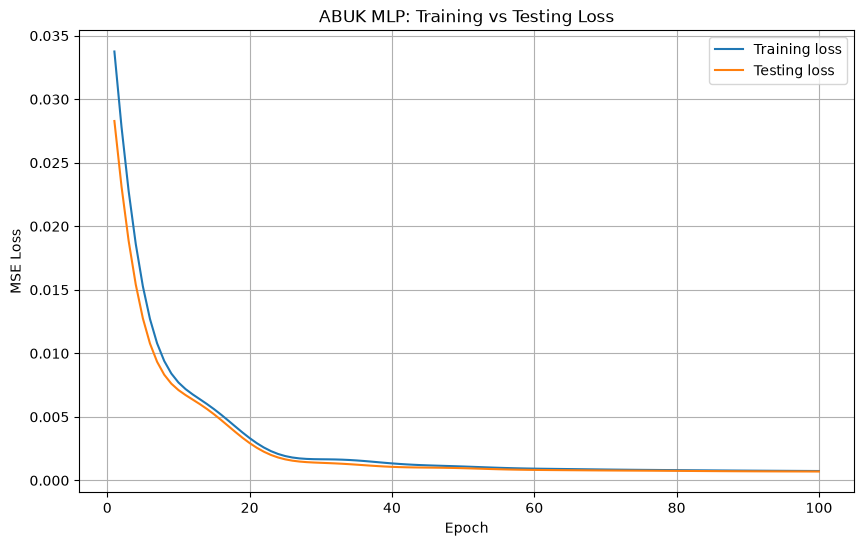

In [19]:
# Plot training and testing loss

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training loss"
)

plt.plot(
    range(1, epochs + 1),
    test_losses,
    label="Testing loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ABUK MLP: Training vs Testing Loss")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Generate predictions for training and testing data

model.eval()

with torch.no_grad():
    train_predictions = model(X_train_tensor).numpy().flatten()
    test_predictions = model(X_test_tensor).numpy().flatten()

actual_train = y_train.values
actual_test = y_test.values

print("Training predictions:", train_predictions.shape)
print("Testing predictions:", test_predictions.shape)

print("\nFirst 10 testing predictions:")
print(test_predictions[:10])

print("\nFirst 10 actual returns:")
print(actual_test[:10])

Training predictions: (2280,)
Testing predictions: (571,)

First 10 testing predictions:
[-0.02452578  0.01393139 -0.01137555  0.01441125  0.00120091  0.02736267
  0.02627691 -0.01019092 -0.01600945 -0.00227813]

First 10 actual returns:
[-0.03085444  0.00571426  0.05681818 -0.01689706  0.04843748  0.01341284
  0.01455879 -0.01449485 -0.04368291 -0.02968312]


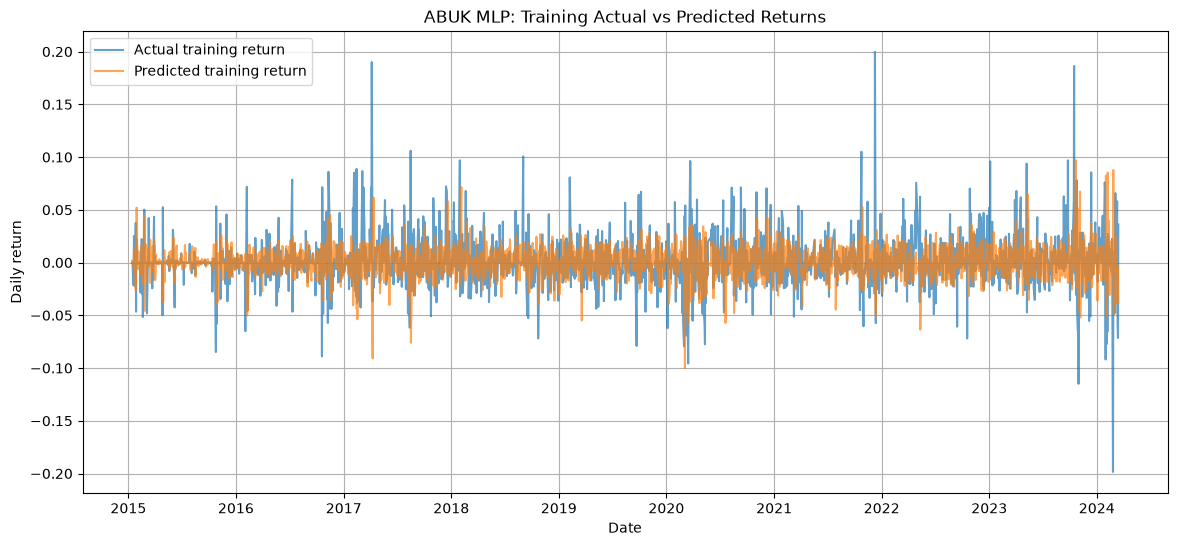

In [21]:
# Plot actual vs predicted returns

train_dates = df["date"].iloc[:split_index]
test_dates = df["date"].iloc[split_index:]

plt.figure(figsize=(14, 6))

plt.plot(
    train_dates,
    actual_train,
    label="Actual training return",
    alpha=0.7
)

plt.plot(
    train_dates,
    train_predictions,
    label="Predicted training return",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.title("ABUK MLP: Training Actual vs Predicted Returns")
plt.legend()
plt.grid(True)

plt.show()

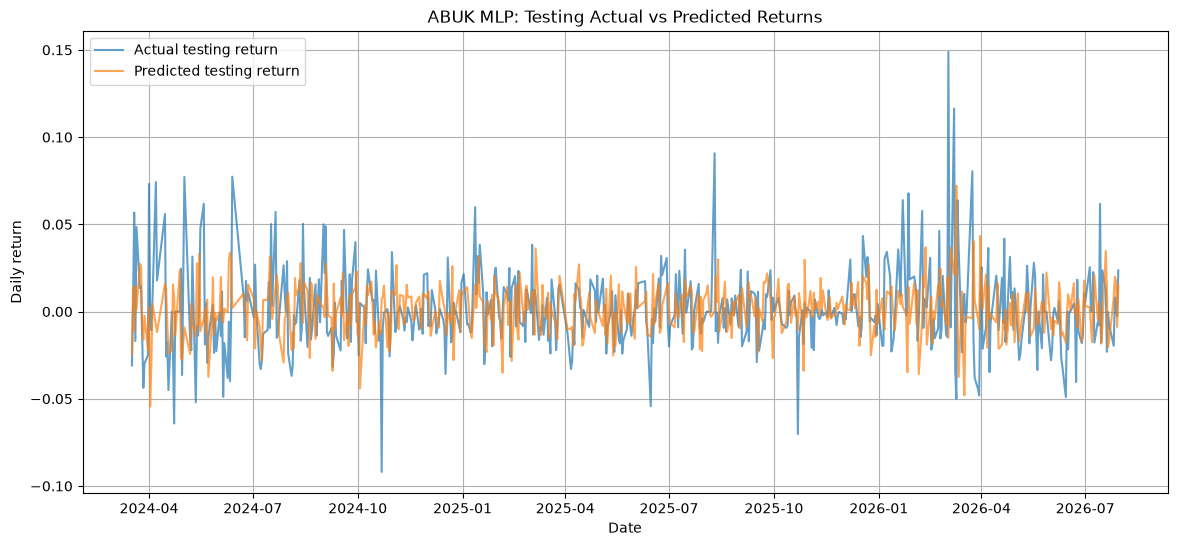

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    actual_test,
    label="Actual testing return",
    alpha=0.7
)

plt.plot(
    test_dates,
    test_predictions,
    label="Predicted testing return",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.title("ABUK MLP: Testing Actual vs Predicted Returns")
plt.legend()
plt.grid(True)

plt.show()

## 10. Experiment 1: Effect of Hidden Layers

The number of hidden layers is varied to investigate how network depth affects prediction performance. The testing loss is used as the main measure for comparing the different architectures because it represents performance on unseen data.

In [47]:
def create_mlp(input_size=5, hidden_size=32, num_hidden_layers=2):
    layers = []

    # First hidden layer
    layers.append(nn.Linear(input_size, hidden_size))
    layers.append(nn.ReLU())

    # Additional hidden layers
    for _ in range(num_hidden_layers - 1):
        layers.append(nn.Linear(hidden_size, hidden_size))
        layers.append(nn.ReLU())

    # Output layer
    layers.append(nn.Linear(hidden_size, 1))

    return nn.Sequential(*layers)

### Hidden Layer Results

Increasing the number of hidden layers generally improved testing performance. The four-layer model achieved the lowest testing loss in this experiment, with a testing loss of 0.000547.

However, the improvement becomes smaller as the network becomes deeper. This suggests that increasing depth does not necessarily provide unlimited performance improvements.

In [24]:
def train_mlp(hidden_size=32, num_hidden_layers=2, epochs=100, learning_rate=0.001):
    
    model = create_mlp(
        input_size=5,
        hidden_size=hidden_size,
        num_hidden_layers=num_hidden_layers
    )

    loss_function = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        # Training
        model.train()

        predictions = model(X_train_tensor)

        train_loss = loss_function(
            predictions,
            y_train_tensor
        )

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # Testing
        model.eval()

        with torch.no_grad():
            test_predictions = model(X_test_tensor)

            test_loss = loss_function(
                test_predictions,
                y_test_tensor
            )

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

    return model, train_losses, test_losses

In [25]:
model_32_2, train_32_2, test_32_2 = train_mlp(
    hidden_size=32,
    num_hidden_layers=2,
    epochs=100
)

print("Final training loss:", train_32_2[-1])
print("Final testing loss:", test_32_2[-1])

Final training loss: 0.0006732309702783823
Final testing loss: 0.0007167622679844499


## 11. Experiment 2: Effect of the Number of Hidden Neurons

The number of neurons in the hidden layers is varied to investigate the effect of network width. Models ranging from 8 to 128 neurons are evaluated using testing loss as the primary comparison metric.

In [26]:
experiments = [
    {"name": "Small", "hidden_size": 8,  "layers": 1, "epochs": 100},
    {"name": "Medium", "hidden_size": 16, "layers": 1, "epochs": 100},
    {"name": "Baseline", "hidden_size": 32, "layers": 2, "epochs": 100},
    {"name": "Large", "hidden_size": 64, "layers": 2, "epochs": 100},
    {"name": "Very Large", "hidden_size": 128, "layers": 3, "epochs": 100}
]

results = []

for experiment in experiments:

    model_exp, train_loss_exp, test_loss_exp = train_mlp(
        hidden_size=experiment["hidden_size"],
        num_hidden_layers=experiment["layers"],
        epochs=experiment["epochs"]
    )

    results.append({
        "Model": experiment["name"],
        "Hidden neurons": experiment["hidden_size"],
        "Hidden layers": experiment["layers"],
        "Epochs": experiment["epochs"],
        "Training loss": train_loss_exp[-1],
        "Testing loss": test_loss_exp[-1]
    })

results_df = pd.DataFrame(results)

results_df

,Model,Hidden neurons,Hidden layers,Epochs,Training loss,Testing loss
0,Small,8,1,100,0.006306,0.005764
1,Medium,16,1,100,0.006105,0.006650
2,Baseline,32,2,100,0.000636,0.000695
3,Large,64,2,100,0.000524,0.000656
4,Very Large,128,3,100,0.000407,0.000627


## 12. Experiment 3: Effect of Training Epochs

The number of training epochs is varied to investigate how the duration of training affects model performance. Both training and testing losses are recorded for each configuration.

In [27]:
epoch_experiments = [10, 25, 50, 100, 200, 500]

epoch_results = []

for num_epochs in epoch_experiments:

    model_exp, train_loss_exp, test_loss_exp = train_mlp(
        hidden_size=32,
        num_hidden_layers=2,
        epochs=num_epochs
    )

    epoch_results.append({
        "Epochs": num_epochs,
        "Training loss": train_loss_exp[-1],
        "Testing loss": test_loss_exp[-1]
    })

epoch_results_df = pd.DataFrame(epoch_results)

epoch_results_df

,Epochs,Training loss,Testing loss
0,10,0.004483,0.004512
1,25,0.000844,0.000878
2,50,0.001008,0.001086
3,100,0.000626,0.000668
4,200,0.000569,0.000683
5,500,0.000471,0.000616


### Epoch Results

Increasing the number of epochs generally reduced training loss, although testing loss did not decrease monotonically. The best testing loss in this experiment occurred at 500 epochs.

The differences between training and testing performance also demonstrate that excessive training can contribute to overfitting, particularly when combined with a high-capacity network.

In [28]:
layer_experiments = [1, 2, 3, 4]

layer_results = []

for num_layers in layer_experiments:

    model_exp, train_loss_exp, test_loss_exp = train_mlp(
        hidden_size=32,
        num_hidden_layers=num_layers,
        epochs=100
    )

    layer_results.append({
        "Hidden layers": num_layers,
        "Training loss": train_loss_exp[-1],
        "Testing loss": test_loss_exp[-1]
    })

layer_results_df = pd.DataFrame(layer_results)

layer_results_df

,Hidden layers,Training loss,Testing loss
0,1,0.001195,0.001126
1,2,0.000589,0.000752
2,3,0.000519,0.000579
3,4,0.000528,0.000547


## 13. Controlled Architecture Comparison

The previous experiments investigated individual aspects of the MLP. A final controlled comparison is performed using several combinations of hidden neurons, hidden layers and training epochs.

The models are compared using the same train/test split and a fixed random seed to improve reproducibility. The model with the lowest testing loss is selected as the final architecture.

In [29]:
results_df

,Model,Hidden neurons,Hidden layers,Epochs,Training loss,Testing loss
0,Small,8,1,100,0.006306,0.005764
1,Medium,16,1,100,0.006105,0.006650
2,Baseline,32,2,100,0.000636,0.000695
3,Large,64,2,100,0.000524,0.000656
4,Very Large,128,3,100,0.000407,0.000627


In [30]:
epoch_results_df

,Epochs,Training loss,Testing loss
0,10,0.004483,0.004512
1,25,0.000844,0.000878
2,50,0.001008,0.001086
3,100,0.000626,0.000668
4,200,0.000569,0.000683
5,500,0.000471,0.000616


### Selecting the Final Architecture

The best model in the controlled comparison uses 32 neurons per hidden layer, 4 hidden layers and 100 epochs. It achieved a testing loss of approximately 0.000567.

This model is selected because it provides the best testing performance among the compared architectures rather than simply having the lowest training loss.

In [31]:
# Make neural network experiments reproducible

torch.manual_seed(42)
np.random.seed(42)

## 14. Final Model

Based on the architecture experiments, the final MLP uses 32 neurons in each of four hidden layers and is trained for 100 epochs.

The final model is evaluated using MSE, RMSE and MAE on the unseen testing data.

In [37]:
torch.manual_seed(42)

final_model, final_train_losses, final_test_losses = train_mlp(
    hidden_size=128,
    num_hidden_layers=4,
    epochs=500
)

print("Final training loss:", final_train_losses[-1])
print("Final testing loss:", final_test_losses[-1])

Final training loss: 0.00010708368063205853
Final testing loss: 0.0010309406789019704


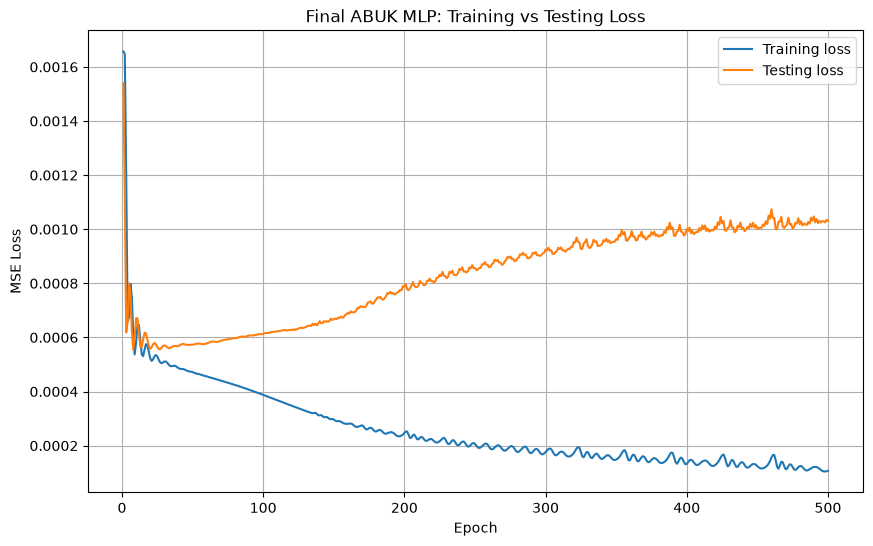

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 501),
    final_train_losses,
    label="Training loss"
)

plt.plot(
    range(1, 501),
    final_test_losses,
    label="Testing loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Final ABUK MLP: Training vs Testing Loss")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
final_model.eval()

with torch.no_grad():
    final_train_predictions = (
        final_model(X_train_tensor)
        .numpy()
        .flatten()
    )

    final_test_predictions = (
        final_model(X_test_tensor)
        .numpy()
        .flatten()
    )

print("Training predictions:", final_train_predictions.shape)
print("Testing predictions:", final_test_predictions.shape)

Training predictions: (2280,)
Testing predictions: (571,)


### Final Model Evaluation

The final model achieves the following performance on the training and testing datasets.

In [35]:
# Calculate evaluation metrics

def calculate_metrics(actual, predicted):
    mse = np.mean((actual - predicted) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(actual - predicted))
    
    return mse, rmse, mae


train_mse, train_rmse, train_mae = calculate_metrics(
    y_train.values,
    final_train_predictions
)

test_mse, test_rmse, test_mae = calculate_metrics(
    y_test.values,
    final_test_predictions
)

print("TRAINING RESULTS")
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("MAE :", train_mae)

print("\nTESTING RESULTS")
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("MAE :", test_mae)

TRAINING RESULTS
MSE : 0.00011047566738223898
RMSE: 0.010510740572492454
MAE : 0.006637081095004978

TESTING RESULTS
MSE : 0.0010309407720299855
RMSE: 0.03210826641271661
MAE : 0.02295981955345153


### Actual vs Predicted Returns

The following visualisation compares the actual returns with the returns predicted by the final MLP on the unseen testing period.

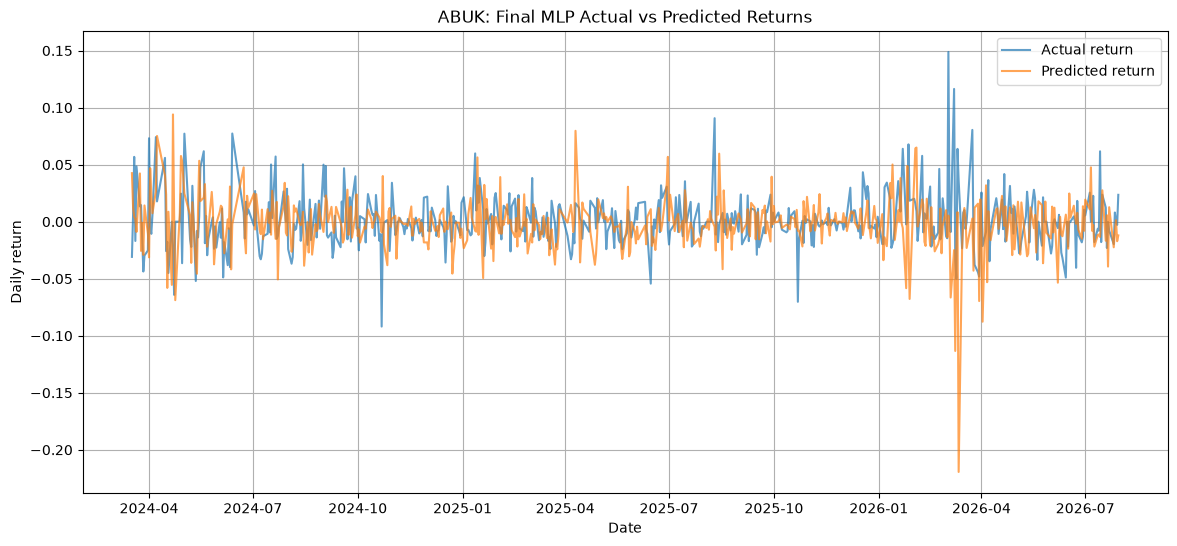

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    actual_test,
    label="Actual return",
    alpha=0.7
)

plt.plot(
    test_dates,
    final_test_predictions,
    label="Predicted return",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.title("ABUK: Final MLP Actual vs Predicted Returns")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
torch.manual_seed(42)

final_experiments = [
    {"name": "32 neurons, 3 layers, 100 epochs", "neurons": 32, "layers": 3, "epochs": 100},
    {"name": "32 neurons, 4 layers, 100 epochs", "neurons": 32, "layers": 4, "epochs": 100},
    {"name": "32 neurons, 4 layers, 200 epochs", "neurons": 32, "layers": 4, "epochs": 200},
    {"name": "64 neurons, 3 layers, 100 epochs", "neurons": 64, "layers": 3, "epochs": 100},
    {"name": "64 neurons, 4 layers, 100 epochs", "neurons": 64, "layers": 4, "epochs": 100},
    {"name": "64 neurons, 4 layers, 200 epochs", "neurons": 64, "layers": 4, "epochs": 200},
    {"name": "128 neurons, 3 layers, 100 epochs", "neurons": 128, "layers": 3, "epochs": 100},
    {"name": "128 neurons, 4 layers, 100 epochs", "neurons": 128, "layers": 4, "epochs": 100},
]

final_results = []

for experiment in final_experiments:

    torch.manual_seed(42)

    model_exp, train_loss_exp, test_loss_exp = train_mlp(
        hidden_size=experiment["neurons"],
        num_hidden_layers=experiment["layers"],
        epochs=experiment["epochs"]
    )

    final_results.append({
        "Model": experiment["name"],
        "Neurons": experiment["neurons"],
        "Layers": experiment["layers"],
        "Epochs": experiment["epochs"],
        "Training loss": train_loss_exp[-1],
        "Testing loss": test_loss_exp[-1]
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values("Testing loss")

,Model,Neurons,Layers,Epochs,Training loss,Testing loss
1,"32 neurons, 4 layers, 100 epochs",32,4,100,0.000495,0.000567
3,"64 neurons, 3 layers, 100 epochs",64,3,100,0.000454,0.000571
4,"64 neurons, 4 layers, 100 epochs",64,4,100,0.000431,0.000581
6,"128 neurons, 3 layers, 100 epochs",128,3,100,0.000418,0.000583
0,"32 neurons, 3 layers, 100 epochs",32,3,100,0.000477,0.000586
2,"32 neurons, 4 layers, 200 epochs",32,4,200,0.000448,0.000588
7,"128 neurons, 4 layers, 100 epochs",128,4,100,0.000388,0.000613
5,"64 neurons, 4 layers, 200 epochs",64,4,200,0.000275,0.000749


In [39]:
# Train the final selected model

torch.manual_seed(42)

final_model, final_train_losses, final_test_losses = train_mlp(
    hidden_size=32,
    num_hidden_layers=4,
    epochs=100
)

print("Final model:")
print("Hidden neurons: 32")
print("Hidden layers: 4")
print("Epochs: 100")
print()
print("Final training loss:", final_train_losses[-1])
print("Final testing loss:", final_test_losses[-1])

Final model:
Hidden neurons: 32
Hidden layers: 4
Epochs: 100

Final training loss: 0.0004949980648234487
Final testing loss: 0.0005668809753842652


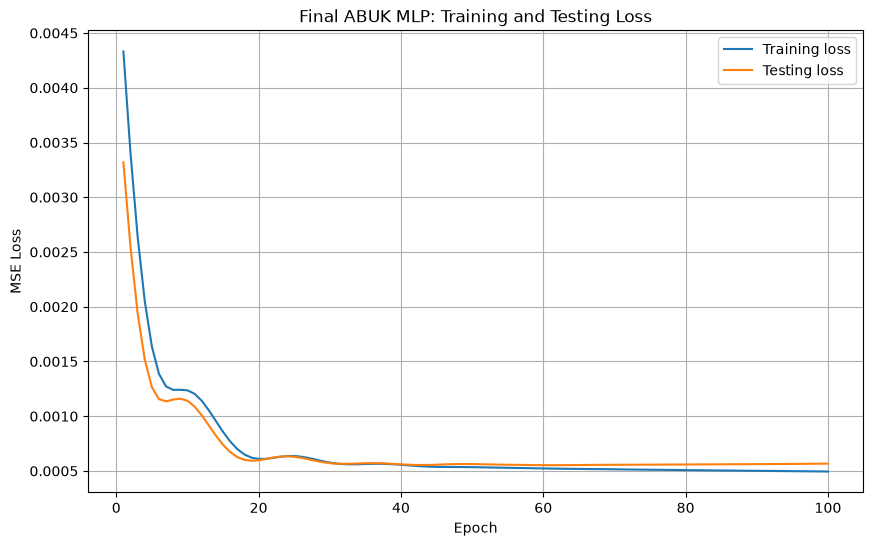

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 101),
    final_train_losses,
    label="Training loss"
)

plt.plot(
    range(1, 101),
    final_test_losses,
    label="Testing loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Final ABUK MLP: Training and Testing Loss")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
# Generate final predictions

final_model.eval()

with torch.no_grad():
    final_train_predictions = (
        final_model(X_train_tensor)
        .numpy()
        .flatten()
    )

    final_test_predictions = (
        final_model(X_test_tensor)
        .numpy()
        .flatten()
    )

print("Training predictions:", final_train_predictions.shape)
print("Testing predictions:", final_test_predictions.shape)

Training predictions: (2280,)
Testing predictions: (571,)


In [42]:
# Final evaluation metrics

train_mse, train_rmse, train_mae = calculate_metrics(
    y_train.values,
    final_train_predictions
)

test_mse, test_rmse, test_mae = calculate_metrics(
    y_test.values,
    final_test_predictions
)

print("FINAL MODEL")
print("=" * 40)

print("\nTraining:")
print(f"MSE :  {train_mse:.8f}")
print(f"RMSE:  {train_rmse:.8f}")
print(f"MAE :  {train_mae:.8f}")

print("\nTesting:")
print(f"MSE :  {test_mse:.8f}")
print(f"RMSE:  {test_rmse:.8f}")
print(f"MAE :  {test_mae:.8f}")

FINAL MODEL

Training:
MSE :  0.00049445
RMSE:  0.02223618
MAE :  0.01424127

Testing:
MSE :  0.00056688
RMSE:  0.02380926
MAE :  0.01669691


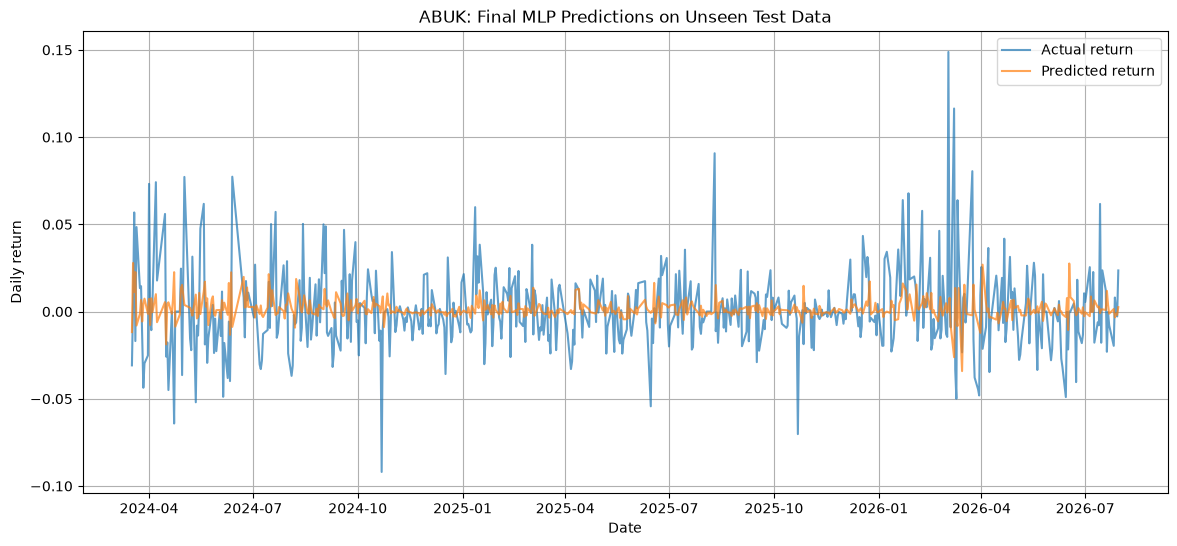

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    actual_test,
    label="Actual return",
    alpha=0.7
)

plt.plot(
    test_dates,
    final_test_predictions,
    label="Predicted return",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.title("ABUK: Final MLP Predictions on Unseen Test Data")
plt.legend()
plt.grid(True)

plt.show()

## 15. Comparison with a Naive Baseline

To determine whether the MLP provides useful predictive information, it is compared against a simple naive baseline.

The baseline predicts the current return using the previous day's return. This provides a simple benchmark that the neural network must outperform to demonstrate useful predictive improvement.

In [44]:
# Naive baseline:
# predict today's return using yesterday's return

baseline_train_predictions = X_train["return_lag_1"].values
baseline_test_predictions = X_test["return_lag_1"].values

baseline_train_mse, baseline_train_rmse, baseline_train_mae = calculate_metrics(
    y_train.values,
    baseline_train_predictions
)

baseline_test_mse, baseline_test_rmse, baseline_test_mae = calculate_metrics(
    y_test.values,
    baseline_test_predictions
)

print("NAIVE BASELINE")
print("=" * 40)

print("\nTraining:")
print(f"MSE :  {baseline_train_mse:.8f}")
print(f"RMSE:  {baseline_train_rmse:.8f}")
print(f"MAE :  {baseline_train_mae:.8f}")

print("\nTesting:")
print(f"MSE :  {baseline_test_mse:.8f}")
print(f"RMSE:  {baseline_test_rmse:.8f}")
print(f"MAE :  {baseline_test_mae:.8f}")

NAIVE BASELINE

Training:
MSE :  0.00102944
RMSE:  0.03208495
MAE :  0.02083098

Testing:
MSE :  0.00101740
RMSE:  0.03189669
MAE :  0.02256168


## 16. Neural Network Trading Strategy

The predictions from the final MLP are converted into a simple trading strategy.

If the predicted return is positive, the strategy holds the stock. If the predicted return is zero or negative, the strategy remains out of the market.

The strategy starts with an initial portfolio value of £1 and does not include transaction costs, commissions, slippage or taxes.

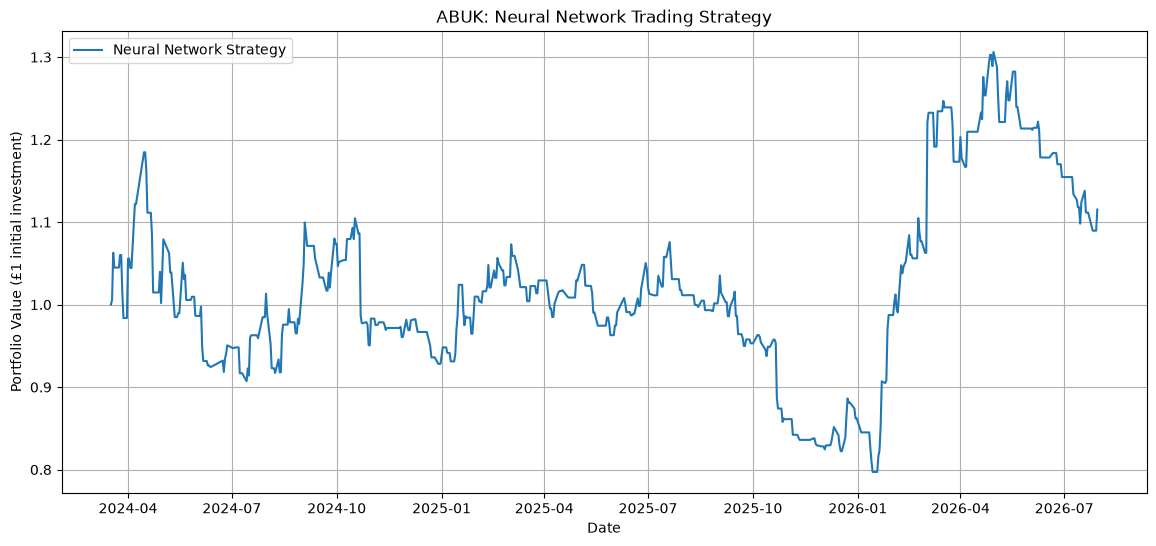

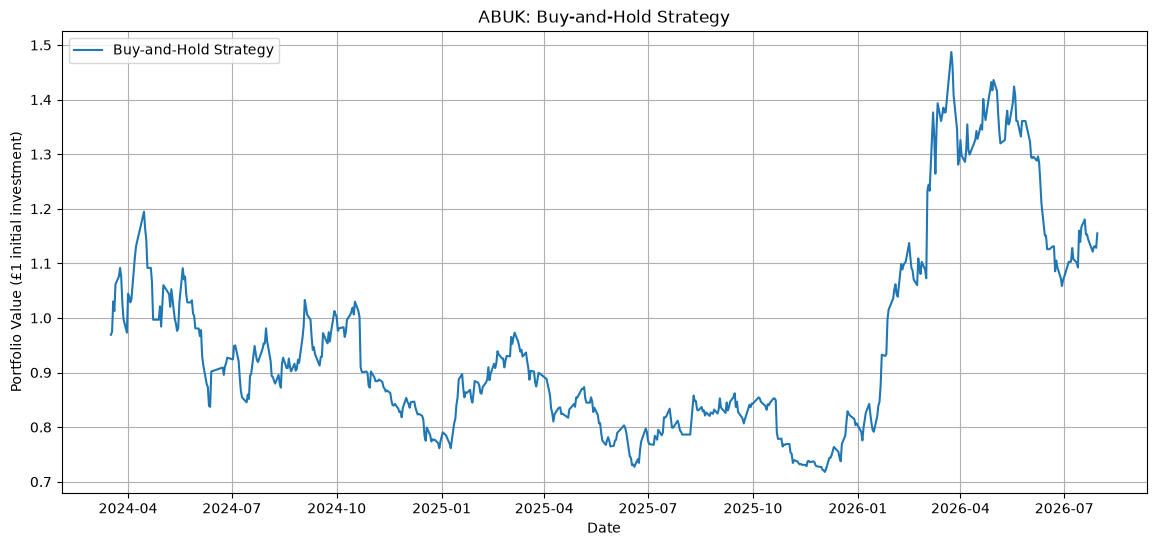

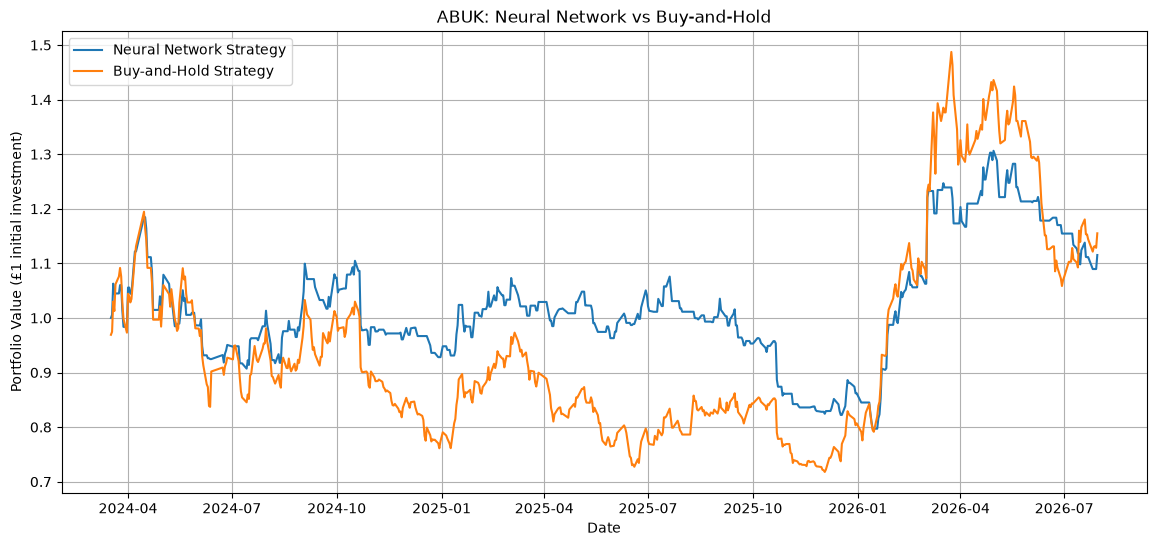

NEURAL NETWORK STRATEGY
Final portfolio value: £1.1153
Cumulative return: 11.53%

BUY-AND-HOLD STRATEGY
Final portfolio value: £1.1551
Cumulative return: 15.51%


In [45]:
# ==========================================
# NEURAL NETWORK vs BUY-AND-HOLD STRATEGY
# ==========================================

# Neural network trading signal:
# Buy/hold when predicted return is positive
# Stay out of the market when predicted return is zero/negative

nn_signal = (final_test_predictions > 0).astype(int)

# Returns generated by the neural-network strategy
nn_strategy_returns = nn_signal * actual_test

# Buy-and-hold strategy:
# Always invested in the stock
buy_hold_returns = actual_test

# Start both strategies with £1
nn_equity = np.cumprod(1 + nn_strategy_returns)
buy_hold_equity = np.cumprod(1 + buy_hold_returns)

# ------------------------------------------
# 1. Neural Network Strategy
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    nn_equity,
    label="Neural Network Strategy"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (£1 initial investment)")
plt.title("ABUK: Neural Network Trading Strategy")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------
# 2. Buy-and-Hold Strategy
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    buy_hold_equity,
    label="Buy-and-Hold Strategy"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (£1 initial investment)")
plt.title("ABUK: Buy-and-Hold Strategy")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------
# 3. Direct Comparison
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    nn_equity,
    label="Neural Network Strategy"
)

plt.plot(
    test_dates,
    buy_hold_equity,
    label="Buy-and-Hold Strategy"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (£1 initial investment)")
plt.title("ABUK: Neural Network vs Buy-and-Hold")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------
# Final results
# ------------------------------------------

print("NEURAL NETWORK STRATEGY")
print(f"Final portfolio value: £{nn_equity[-1]:.4f}")
print(f"Cumulative return: {(nn_equity[-1] - 1) * 100:.2f}%")

print("\nBUY-AND-HOLD STRATEGY")
print(f"Final portfolio value: £{buy_hold_equity[-1]:.4f}")
print(f"Cumulative return: {(buy_hold_equity[-1] - 1) * 100:.2f}%")

## Final Model

The final selected model is a multilayer perceptron (MLP) with:

- 5 input features consisting of the five previous daily returns
- 4 hidden layers
- 32 neurons in each hidden layer
- ReLU activation functions
- 1 output neuron predicting the next daily return
- Adam optimiser
- Learning rate of 0.001
- 100 training epochs

The model was selected based on testing performance rather than training loss.

In [46]:
# ==========================================
# FINAL RESULTS SUMMARY
# ==========================================

final_summary = pd.DataFrame({
    "Strategy": [
        "Naive baseline",
        "MLP",
        "Buy-and-Hold"
    ],
    "Test MSE": [
        baseline_test_mse,
        test_mse,
        np.nan
    ],
    "Test RMSE": [
        baseline_test_rmse,
        test_rmse,
        np.nan
    ],
    "Test MAE": [
        baseline_test_mae,
        test_mae,
        np.nan
    ],
    "Cumulative Return (%)": [
        np.nan,
        (nn_equity[-1] - 1) * 100,
        (buy_hold_equity[-1] - 1) * 100
    ]
})

final_summary

,Strategy,Test MSE,Test RMSE,Test MAE,Cumulative Return (%)
0,Naive baseline,0.001017,0.031897,0.022562,NaN
1,MLP,0.000567,0.023809,0.016697,11.529467
2,Buy-and-Hold,NaN,NaN,NaN,15.506328


# 17. Conclusion

The experiments investigated the effect of neural network architecture and training duration on ABUK stock return prediction.

The results show that increasing model complexity does not necessarily result in better generalisation. Increasing the number of hidden layers initially improved testing performance, but larger networks and longer training could lead to overfitting. In particular, highly complex models achieved very low training losses while producing worse testing losses.

The selected model contains four hidden layers with 32 neurons per layer and is trained for 100 epochs. It achieved a testing MSE of 0.000567, compared with 0.001017 for the naive baseline. This represents an approximately 44.3% reduction in testing MSE.

However, improved prediction accuracy did not translate directly into better investment performance. The neural-network trading strategy achieved a cumulative return of 11.53%, whereas the buy-and-hold strategy achieved 15.51%.

Overall, the results demonstrate that an appropriately sized neural network can improve prediction accuracy compared with a simple baseline, but greater model complexity does not necessarily lead to better generalisation or better investment returns. Model selection should therefore consider unseen-data performance and potential overfitting rather than training loss alone.